In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

In [17]:
df = pd.read_csv("../2022_output/combined_races.csv")
df

,Date,R,D,Vote Difference,Margin,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots,Race
0,2022-11-14,89150,79188,9962,0.059179,168338,346428,Alpine,18,CD-3
1,2022-11-15,89725,79595,10130,0.059828,169320,344949,Alpine,18,CD-3
2,2022-11-16,96334,85690,10644,0.058476,182024,297717,Alpine,18,CD-3
3,2022-11-17,99970,91154,8816,0.046127,191124,277382,Alpine,18,CD-3
4,2022-11-18,102427,92948,9479,0.048517,195375,268005,Alpine,18,CD-3
...,...,...,...,...,...,...,...,...,...,...
527,2022-12-02,84647,84627,20,0.000118,169274,3150,San Bernardino,3150,AD-47
528,2022-12-05,84669,84635,34,0.000201,169304,2250,San Bernardino,2250,AD-47
529,2022-12-06,84686,84651,35,0.000207,169337,2050,San Bernardino,2050,AD-47
530,2022-12-07,84723,84654,69,0.000407,169377,1851,San Bernardino,1851,AD-47


In [18]:
# Unique date counts per race
df.groupby(["Race", "Jurisdiction"])["Date"].count().unstack("Jurisdiction").max(axis=1)

Race
AD-40    14.0
AD-47    16.0
AD-7     15.0
CD-13    16.0
CD-22    19.0
CD-27    16.0
CD-3     18.0
CD-41    14.0
CD-45    16.0
CD-47    14.0
CD-49    19.0
SD-16    10.0
dtype: float64

In [19]:
# Earliest date per race (when data first appeared)
df.groupby(["Race", "Jurisdiction"])["Date"].min().unstack("Jurisdiction").max(axis=1)

Race
AD-40    2022-11-16
AD-47    2022-11-16
AD-7     2022-11-16
CD-13    2022-11-14
CD-22    2022-11-14
CD-27    2022-11-14
CD-3     2022-11-14
CD-41    2022-11-14
CD-45    2022-11-14
CD-47    2022-11-14
CD-49    2022-11-14
SD-16    2022-11-28
dtype: str

--- 2022 Election Results & Flips ---
Race: AD-40 | Final Winner: D
  -> FLIP: Flipped to R on 2022-11-17 (E+9)
  -> FLIP: Flipped to D on 2022-11-21 (E+13)
Race: AD-47 | Final Winner: R
  -> FLIP: Flipped to R on 2022-12-02 (E+24)
Race: AD-7 | Final Winner: R
  -> FLIP: Flipped to R on 2022-11-21 (E+13)
Race: CD-13 | Final Winner: R
  -> FLIP: Flipped to D on 2022-11-15 (E+7)
  -> FLIP: Flipped to R on 2022-11-17 (E+9)
Race: CD-22 | Final Winner: R
Race: CD-27 | Final Winner: R
Race: CD-3 | Final Winner: R
Race: CD-41 | Final Winner: R
Race: CD-45 | Final Winner: R
Race: CD-47 | Final Winner: D
Race: CD-49 | Final Winner: D
Race: SD-16 | Final Winner: D
  -> FLIP: Flipped to D on 2022-12-05 (E+27)
-------------------------------------



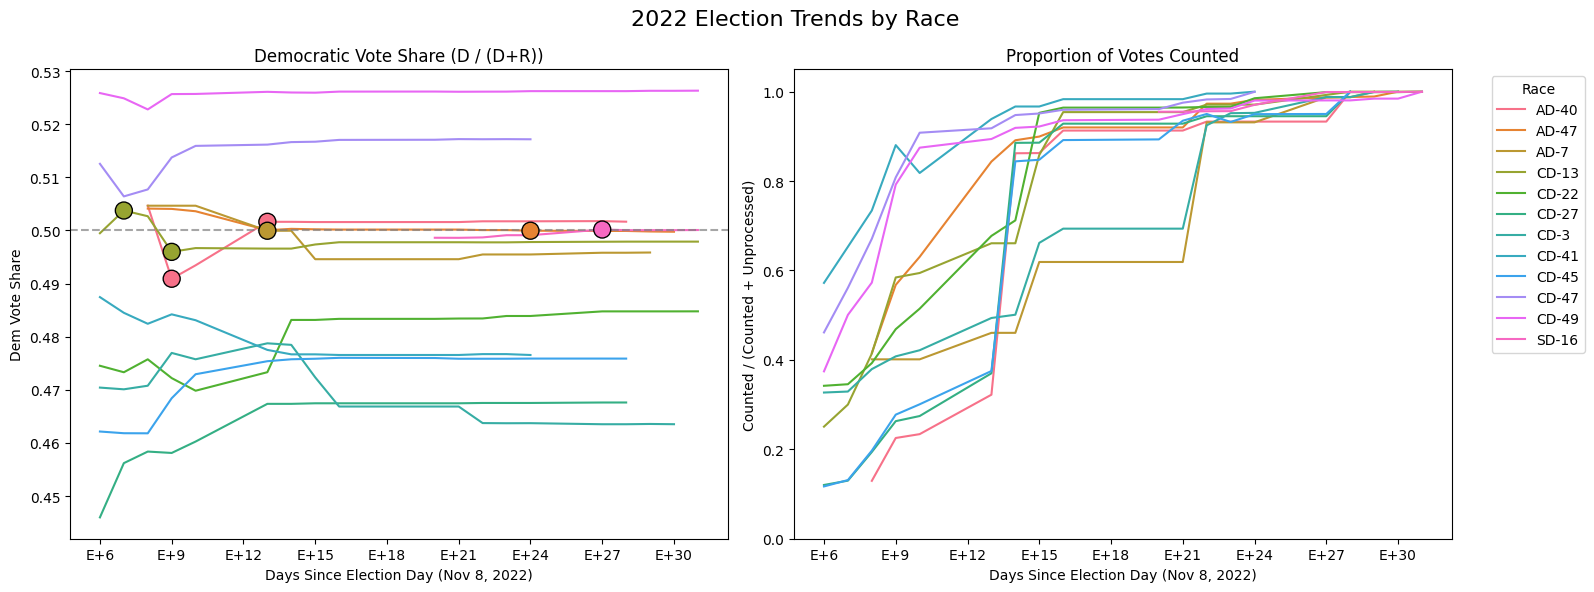

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

# 2022 election day
ELECTION_DAY = pd.to_datetime('2022-11-08')

race_df = df.copy()

# Deduplicate: one row per Race per Date
race_df = race_df.drop_duplicates(subset=['Race', 'Date']).copy()
race_df['Date'] = pd.to_datetime(race_df['Date'])
race_df = race_df.sort_values(['Race', 'Date'])

race_df['Days_Since_Election'] = (race_df['Date'] - ELECTION_DAY).dt.days

# Coerce numerics
for col in ['D', 'R', 'Total Votes Cast', 'Total Unprocessed Ballots*']:
    if col in race_df.columns:
        race_df[col] = pd.to_numeric(race_df[col].astype(str).str.replace(',', ''), errors='coerce')

race_df['Dem_Vote_Share'] = race_df['D'] / (race_df['D'] + race_df['R'])
race_df['Prop_Votes_Received'] = race_df['Total Votes Cast'] / (
    race_df['Total Votes Cast'] + race_df['Total Unprocessed Ballots*']
)

# Track flip coordinates
flip_points = []
unique_races = sorted(race_df['Race'].unique())

print("--- 2022 Election Results & Flips ---")
for race, group in race_df.groupby('Race'):
    group = group.sort_values('Date').reset_index(drop=True)
    if len(group) == 0:
        continue
    last_drop = group.iloc[-1]
    final_winner = 'D' if last_drop['Dem_Vote_Share'] > 0.5 else ('R' if last_drop['Dem_Vote_Share'] < 0.5 else 'Tie')
    print(f"Race: {race} | Final Winner: {final_winner}")

    current_leader = 'D' if group.iloc[0]['Dem_Vote_Share'] > 0.5 else ('R' if group.iloc[0]['Dem_Vote_Share'] < 0.5 else 'Tie')
    for i in range(1, len(group)):
        row = group.iloc[i]
        day_leader = 'D' if row['Dem_Vote_Share'] > 0.5 else ('R' if row['Dem_Vote_Share'] < 0.5 else 'Tie')
        if day_leader != 'Tie' and day_leader != current_leader:
            days_e = row['Days_Since_Election']
            e_str = f"E+{int(days_e)}" if days_e > 0 else (f"E{int(days_e)}" if days_e < 0 else "E")
            print(f"  -> FLIP: Flipped to {day_leader} on {row['Date'].strftime('%Y-%m-%d')} ({e_str})")
            flip_points.append({'Race': race, 'Days_Since_Election': days_e, 'Dem_Vote_Share': row['Dem_Vote_Share']})
            current_leader = day_leader
print("-------------------------------------\n")

def e_plus_formatter(x, pos):
    val = round(x)
    if val > 0: return f"E+{val}"
    elif val < 0: return f"E{val}"
    else: return "E"

formatter = FuncFormatter(e_plus_formatter)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('2022 Election Trends by Race', fontsize=16)

sns.lineplot(data=race_df, x='Days_Since_Election', y='Dem_Vote_Share',
             hue='Race', hue_order=unique_races, ax=axes[0])
if flip_points:
    flip_df = pd.DataFrame(flip_points)
    sns.scatterplot(data=flip_df, x='Days_Since_Election', y='Dem_Vote_Share',
                    hue='Race', hue_order=unique_races, ax=axes[0],
                    s=150, edgecolor='black', zorder=5, legend=False)
axes[0].set_title('Democratic Vote Share (D / (D+R))')
axes[0].set_ylabel('Dem Vote Share')
axes[0].set_xlabel('Days Since Election Day (Nov 8, 2022)')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].xaxis.set_major_formatter(formatter)
axes[0].get_legend().remove()

sns.lineplot(data=race_df, x='Days_Since_Election', y='Prop_Votes_Received',
             hue='Race', hue_order=unique_races, ax=axes[1])
axes[1].set_title('Proportion of Votes Counted')
axes[1].set_ylabel('Counted / (Counted + Unprocessed)')
axes[1].set_xlabel('Days Since Election Day (Nov 8, 2022)')
axes[1].set_ylim(0, 1.05)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_formatter(formatter)
axes[1].legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

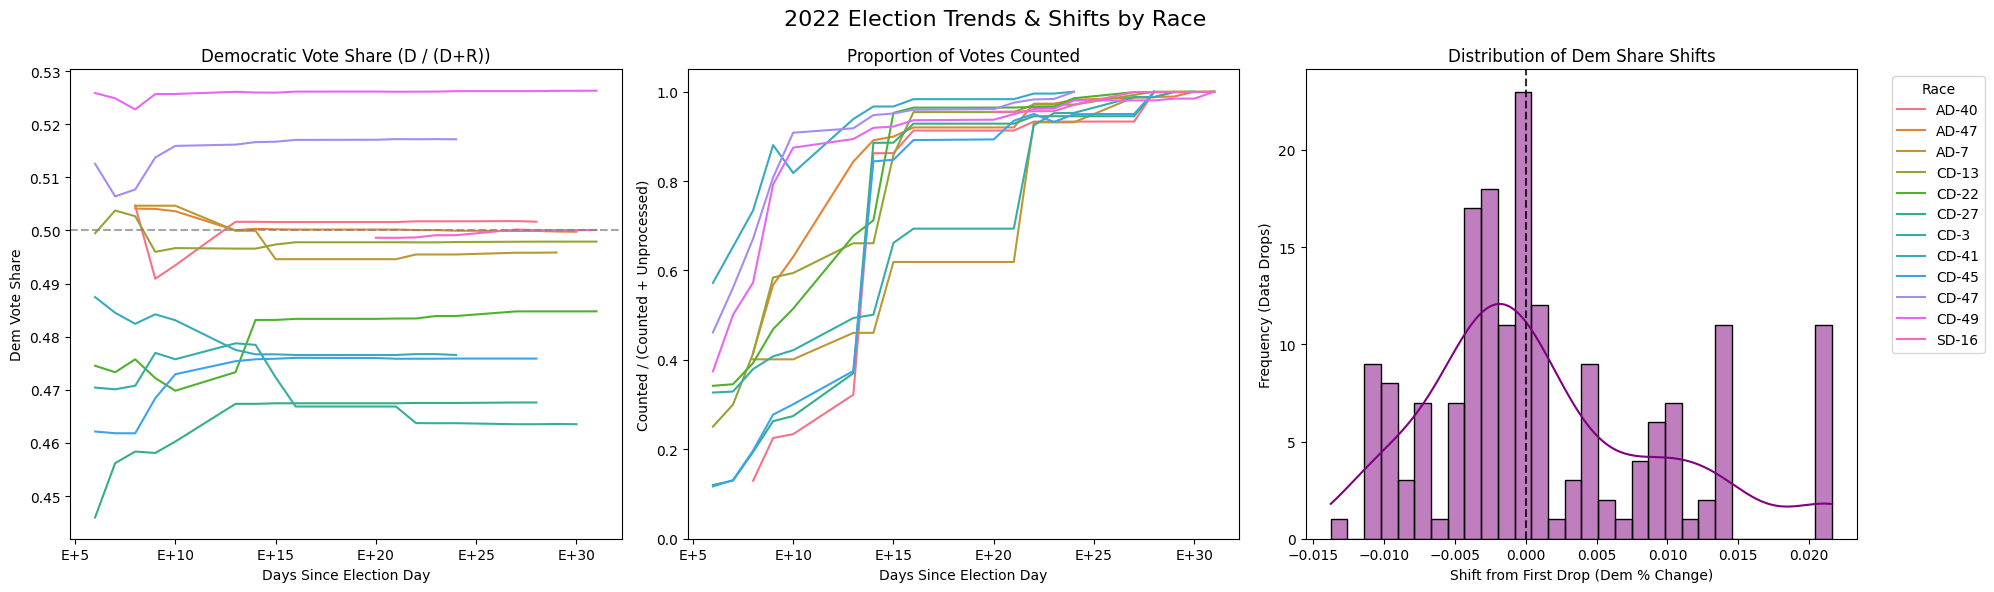

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

ELECTION_DAY = pd.to_datetime('2022-11-08')

race_df2 = df.drop_duplicates(subset=['Race', 'Date']).copy()
race_df2['Date'] = pd.to_datetime(race_df2['Date'])
race_df2 = race_df2.sort_values(['Race', 'Date'])
race_df2['Days_Since_Election'] = (race_df2['Date'] - ELECTION_DAY).dt.days

for col in ['D', 'R', 'Total Votes Cast', 'Total Unprocessed Ballots*']:
    if col in race_df2.columns:
        race_df2[col] = pd.to_numeric(race_df2[col].astype(str).str.replace(',', ''), errors='coerce')

race_df2['Dem_Vote_Share'] = race_df2['D'] / (race_df2['D'] + race_df2['R'])
race_df2['Prop_Votes_Received'] = race_df2['Total Votes Cast'] / (
    race_df2['Total Votes Cast'] + race_df2['Total Unprocessed Ballots*']
)
race_df2['First_Drop_Dem_Share'] = race_df2.groupby('Race')['Dem_Vote_Share'].transform('first')
race_df2['Dem_Share_Diff'] = race_df2['Dem_Vote_Share'] - race_df2['First_Drop_Dem_Share']

first_dates = race_df2.groupby('Race')['Date'].transform('min')
rest_of_data = race_df2[race_df2['Date'] > first_dates]

def e_plus_formatter(x, pos):
    if x > 0: return f"E+{int(x)}"
    elif x < 0: return f"E{int(x)}"
    else: return "E"

formatter = FuncFormatter(e_plus_formatter)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('2022 Election Trends & Shifts by Race', fontsize=16)

sns.lineplot(data=race_df2, x='Days_Since_Election', y='Dem_Vote_Share', hue='Race', ax=axes[0])
axes[0].set_title('Democratic Vote Share (D / (D+R))')
axes[0].set_ylabel('Dem Vote Share')
axes[0].set_xlabel('Days Since Election Day')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].get_legend().remove()

sns.lineplot(data=race_df2, x='Days_Since_Election', y='Prop_Votes_Received', hue='Race', ax=axes[1])
axes[1].set_title('Proportion of Votes Counted')
axes[1].set_ylabel('Counted / (Counted + Unprocessed)')
axes[1].set_xlabel('Days Since Election Day')
axes[1].set_ylim(0, 1.05)
axes[1].xaxis.set_major_formatter(formatter)
axes[1].get_legend().remove()

sns.histplot(data=rest_of_data, x='Dem_Share_Diff', bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Dem Share Shifts')
axes[2].set_xlabel('Shift from First Drop (Dem % Change)')
axes[2].set_ylabel('Frequency (Data Drops)')
axes[2].axvline(0, color='black', linestyle='--', alpha=0.8)

handles, labels = axes[1].get_legend_handles_labels()
axes[2].legend(handles=handles, labels=labels, title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

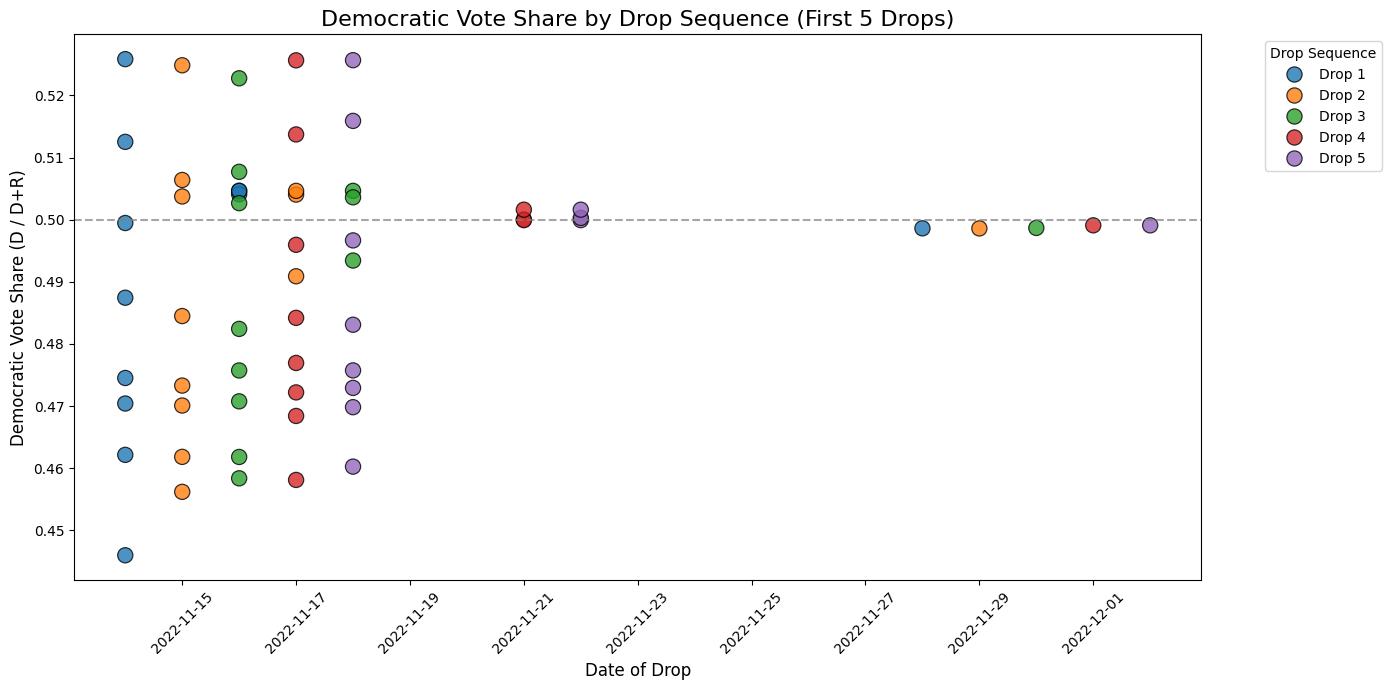

In [22]:
# Drop sequence scatter — all drops, colored by drop number
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ELECTION_DAY = pd.to_datetime('2022-11-08')

plot_df = df.copy()
plot_df['Date'] = pd.to_datetime(plot_df['Date'])
plot_df = plot_df.drop_duplicates(subset=['Race', 'Date'])

for col in ['D', 'R']:
    plot_df[col] = pd.to_numeric(plot_df[col].astype(str).str.replace(',', ''), errors='coerce')

plot_df['Dem_Vote_Share'] = plot_df['D'] / (plot_df['D'] + plot_df['R'])
plot_df = plot_df.sort_values(['Race', 'Date'])
plot_df['Drop_Sequence'] = plot_df.groupby('Race').cumcount() + 1
plot_df['Drop_Number'] = 'Drop ' + plot_df['Drop_Sequence'].astype(str)

# Show just the first 5 drops (election night through ~E+8)
plot_df_early = plot_df[plot_df['Drop_Sequence'] <= 5].sort_values('Drop_Sequence')

plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=plot_df_early, x='Date', y='Dem_Vote_Share',
    hue='Drop_Number', palette='tab10', s=120, edgecolor='black', alpha=0.8
)
plt.title('Democratic Vote Share by Drop Sequence (First 5 Drops)', fontsize=16)
plt.xlabel('Date of Drop', fontsize=12)
plt.ylabel('Democratic Vote Share (D / D+R)', fontsize=12)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Drop Sequence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
# Condensed df: drop jurisdiction rows, keep one row per Race per Date
condensed_df = df.drop(["Jurisdiction", "Unprocessed Ballots"], axis=1, errors='ignore')
condensed_df = condensed_df.drop_duplicates()
condensed_df

,Date,R,D,Vote Difference,Margin,Total Votes Cast,Total Unprocessed Ballots*,Race
0,2022-11-14,89150,79188,9962,0.059179,168338,346428,CD-3
1,2022-11-15,89725,79595,10130,0.059828,169320,344949,CD-3
2,2022-11-16,96334,85690,10644,0.058476,182024,297717,CD-3
3,2022-11-17,99970,91154,8816,0.046127,191124,277382,CD-3
4,2022-11-18,102427,92948,9479,0.048517,195375,268005,CD-3
...,...,...,...,...,...,...,...,...
511,2022-12-02,84647,84627,20,0.000118,169274,3150,AD-47
512,2022-12-05,84669,84635,34,0.000201,169304,2250,AD-47
513,2022-12-06,84686,84651,35,0.000207,169337,2050,AD-47
514,2022-12-07,84723,84654,69,0.000407,169377,1851,AD-47


In [24]:
# Drops per date (how many races reported each day)
condensed_df.groupby('Date')['Race'].count()

Date
2022-11-14     8
2022-11-15     8
2022-11-16    11
2022-11-17    11
2022-11-18    11
2022-11-21    11
2022-11-22    11
2022-11-23    11
2022-11-24    11
2022-11-28    12
2022-11-29    12
2022-11-30    12
2022-12-01    12
2022-12-02    12
2022-12-05     9
2022-12-06    10
2022-12-07     6
2022-12-08     5
2022-12-09     4
Name: Race, dtype: int64

In [25]:
import pandas as pd

# Batch synchronization analysis for 2022
# Since there's no Timestamp, batches = unique dates
sync_df = condensed_df.copy()
sync_df['Date'] = pd.to_datetime(sync_df['Date'])
sync_df = sync_df.sort_values('Date')

total_unique_races = sync_df['Race'].nunique()
date_counts = sync_df.groupby('Date')['Race'].count()

# Main batch = date where majority of races reported
main_batch_dates = date_counts[date_counts > (total_unique_races / 2)].index.tolist()

# Pivot to see which races have data on which main dates
pivot_df = sync_df[sync_df['Date'].isin(main_batch_dates)].pivot(
    index='Race', columns='Date', values='D'
)

synced_races = pivot_df.dropna().index.tolist()
excluded_races = pivot_df[pivot_df.isna().any(axis=1)].index.tolist()

print(f"--- MAIN DAILY BATCHES ---")
for d in main_batch_dates:
    print(f"Date: {d.strftime('%Y-%m-%d')} | Races reporting: {date_counts[d]}")

print(f"\n--- SYNCED RACES (Present on all main batch dates) ---")
print(f"Total Synced: {len(synced_races)}")
print(synced_races)

print(f"\n--- EXCLUDED RACES (Missing at least one main batch date) ---")
for race in excluded_races:
    missed = pivot_df.loc[race][pivot_df.loc[race].isna()].index
    print(f"Race: {race} | Missed: {[d.strftime('%Y-%m-%d') for d in missed]}")

--- MAIN DAILY BATCHES ---
Date: 2022-11-14 | Races reporting: 8
Date: 2022-11-15 | Races reporting: 8
Date: 2022-11-16 | Races reporting: 11
Date: 2022-11-17 | Races reporting: 11
Date: 2022-11-18 | Races reporting: 11
Date: 2022-11-21 | Races reporting: 11
Date: 2022-11-22 | Races reporting: 11
Date: 2022-11-23 | Races reporting: 11
Date: 2022-11-24 | Races reporting: 11
Date: 2022-11-28 | Races reporting: 12
Date: 2022-11-29 | Races reporting: 12
Date: 2022-11-30 | Races reporting: 12
Date: 2022-12-01 | Races reporting: 12
Date: 2022-12-02 | Races reporting: 12
Date: 2022-12-05 | Races reporting: 9
Date: 2022-12-06 | Races reporting: 10

--- SYNCED RACES (Present on all main batch dates) ---
Total Synced: 5
['CD-22', 'CD-27', 'CD-3', 'CD-45', 'CD-49']

--- EXCLUDED RACES (Missing at least one main batch date) ---
Race: AD-40 | Missed: ['2022-11-14', '2022-11-15']
Race: AD-47 | Missed: ['2022-11-14', '2022-11-15']
Race: AD-7 | Missed: ['2022-11-14', '2022-11-15']
Race: CD-13 | Missed

In [26]:
import pandas as pd

# Data integrity check: unprocessed ballots should never increase
check_df = condensed_df.copy()
check_df['Date'] = pd.to_datetime(check_df['Date'])
check_df['Total Unprocessed Ballots*'] = pd.to_numeric(
    check_df['Total Unprocessed Ballots*'].astype(str).str.replace(',', ''), errors='coerce'
)
check_df = check_df.dropna(subset=['Total Unprocessed Ballots*'])
check_df = check_df.sort_values(['Race', 'Date'])
check_df['Unprocessed_Diff'] = check_df.groupby('Race')['Total Unprocessed Ballots*'].diff()

violations = check_df[check_df['Unprocessed_Diff'] > 0]

print("--- Data Integrity Check: Unprocessed Ballots ---")
if violations.empty:
    print("SUCCESS: All races pass the check! Unprocessed ballots only decreased or remained flat.")
else:
    violating_races = violations['Race'].unique()
    print(f"WARNING: Found {len(violations)} instances across {len(violating_races)} races where unprocessed ballots INCREASED.\n")
    for race in violating_races:
        print(f"Race: {race}")
        for _, row in violations[violations['Race'] == race].iterrows():
            curr = int(row['Total Unprocessed Ballots*'])
            diff = int(row['Unprocessed_Diff'])
            prev = curr - diff
            print(f"  -> {row['Date'].strftime('%Y-%m-%d')}: increased by {diff:,} ({prev:,} → {curr:,})")
        print("-" * 40)

--- Data Integrity Check: Unprocessed Ballots ---

Race: CD-41
  -> 2022-11-18: increased by 20,000 (27,000 → 47,000)
----------------------------------------
Race: CD-45
  -> 2022-12-01: increased by 4,398 (11,405 → 15,803)
----------------------------------------


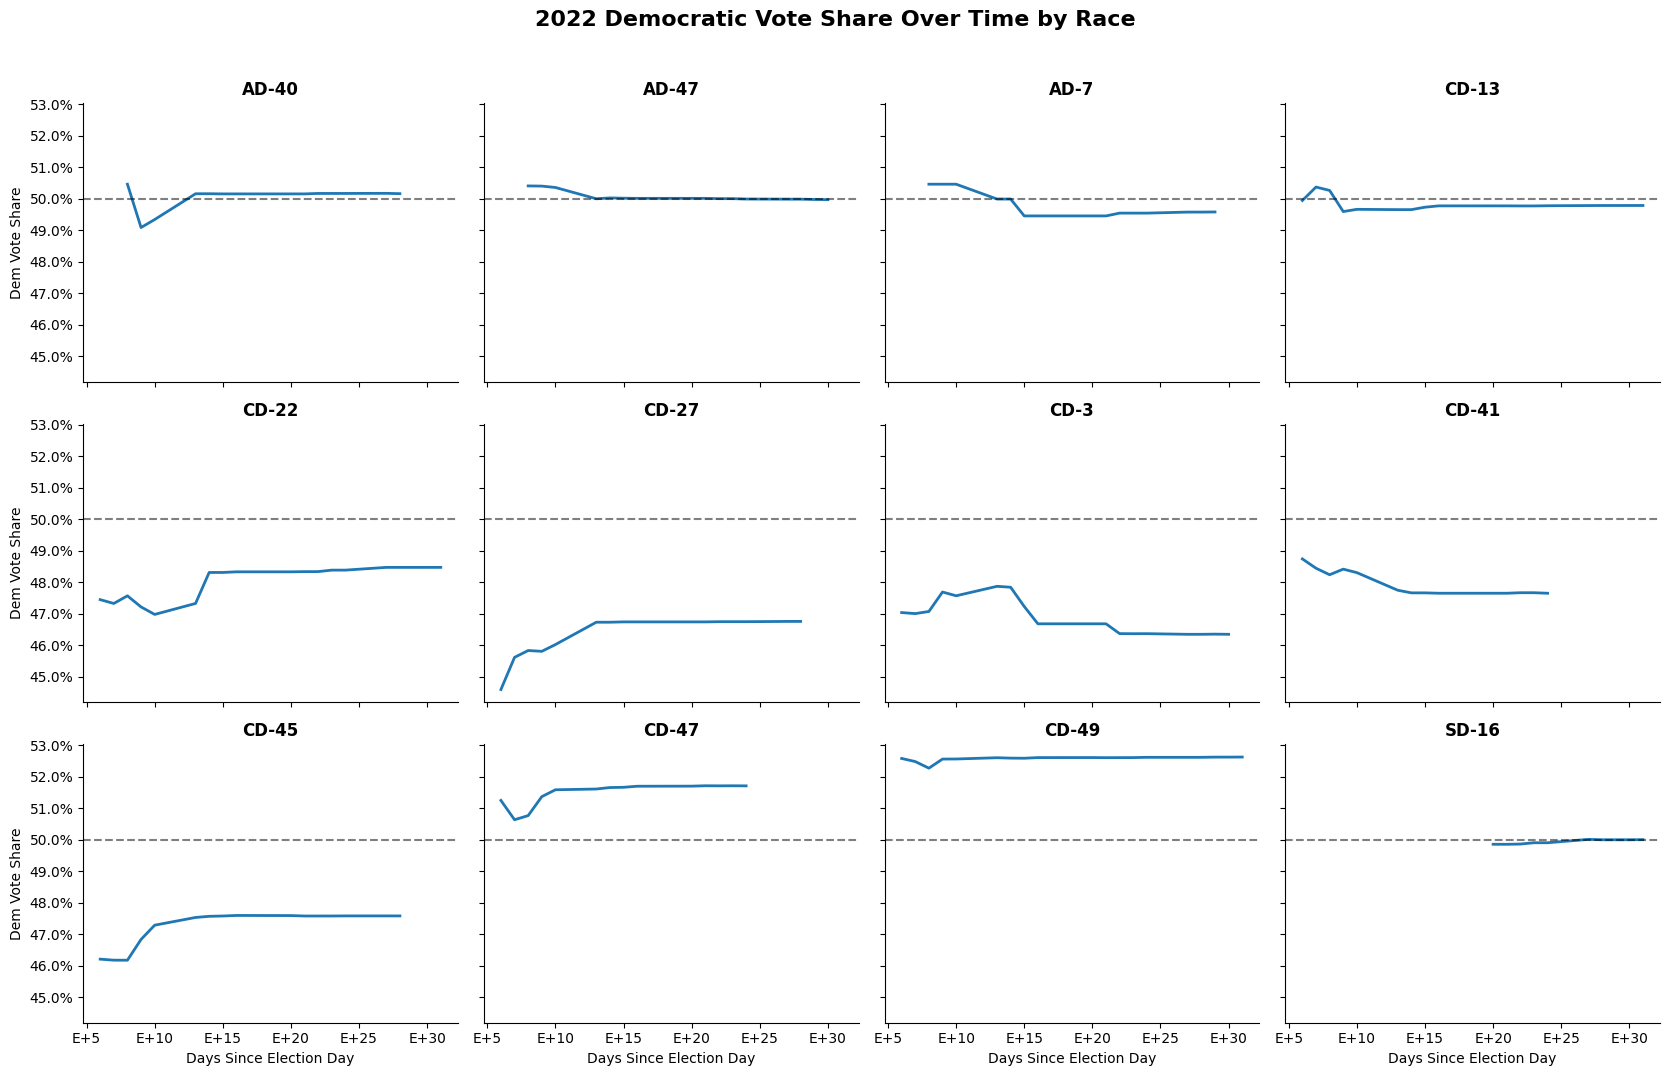

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter

ELECTION_DAY = pd.to_datetime('2022-11-08')

final_df = condensed_df.copy()
final_df['Date'] = pd.to_datetime(final_df['Date'])
final_df = final_df.sort_values(['Race', 'Date'])

for col in ['D', 'R', 'Total Votes Cast', 'Total Unprocessed Ballots*']:
    final_df[col] = pd.to_numeric(final_df[col].astype(str).str.replace(',', ''), errors='coerce')

final_df['Dem_Share'] = final_df['D'] / (final_df['D'] + final_df['R'])
final_df['Days_Since_Election'] = (final_df['Date'] - ELECTION_DAY).dt.days
final_df['Day_Index'] = final_df.groupby('Race').cumcount() + 1

def e_plus_fmt(x, pos):
    val = round(x)
    return f"E+{val}" if val > 0 else (f"E{val}" if val < 0 else "E")

formatter = FuncFormatter(e_plus_fmt)

# Faceted per-race plot
g = sns.relplot(
    data=final_df, x='Days_Since_Election', y='Dem_Share',
    col='Race', col_wrap=4, kind='line',
    linewidth=2, height=3.5, aspect=1.2
)
for ax in g.axes.flat:
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel('Days Since Election Day', fontsize=10)
    ax.set_ylabel('Dem Vote Share', fontsize=10)
    ax.set_title(ax.get_title().replace('Race = ', ''), fontweight='bold')

g.fig.suptitle('2022 Democratic Vote Share Over Time by Race', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

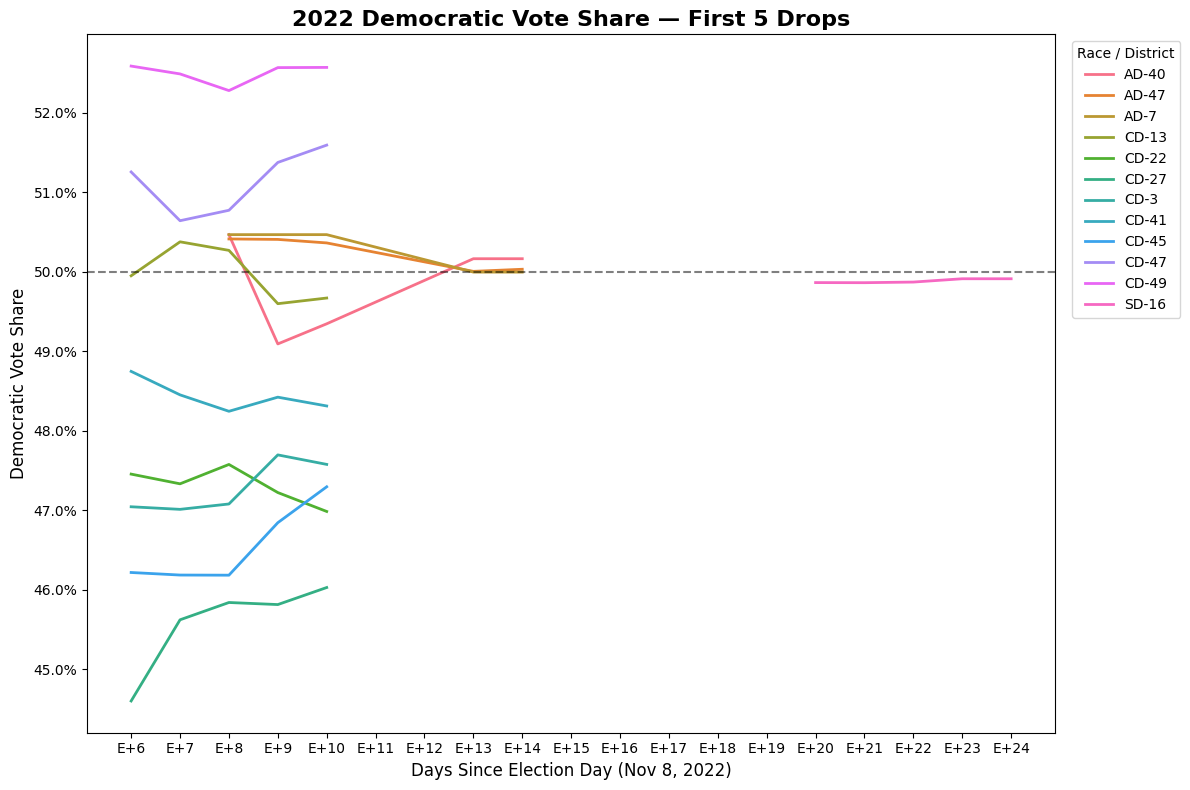

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter

# First 5 drops — use actual days since election on x-axis
plot_df = final_df[final_df['Day_Index'] <= 5].copy()

def e_plus_fmt(x, pos):
    val = round(x)
    return f"E+{val}" if val > 0 else (f"E{val}" if val < 0 else "E")

min_day = int(plot_df['Days_Since_Election'].min())
max_day = int(plot_df['Days_Since_Election'].max())

plt.figure(figsize=(12, 8))
sns.lineplot(data=plot_df, x='Days_Since_Election', y='Dem_Share', hue='Race', linewidth=2)
plt.title('2022 Democratic Vote Share — First 5 Drops', fontsize=16, fontweight='bold')
plt.ylabel('Democratic Vote Share', fontsize=12)
plt.xlabel('Days Since Election Day (Nov 8, 2022)', fontsize=12)
plt.xticks(ticks=range(min_day, max_day + 1), labels=[f'E+{i}' for i in range(min_day, max_day + 1)])
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Race / District')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

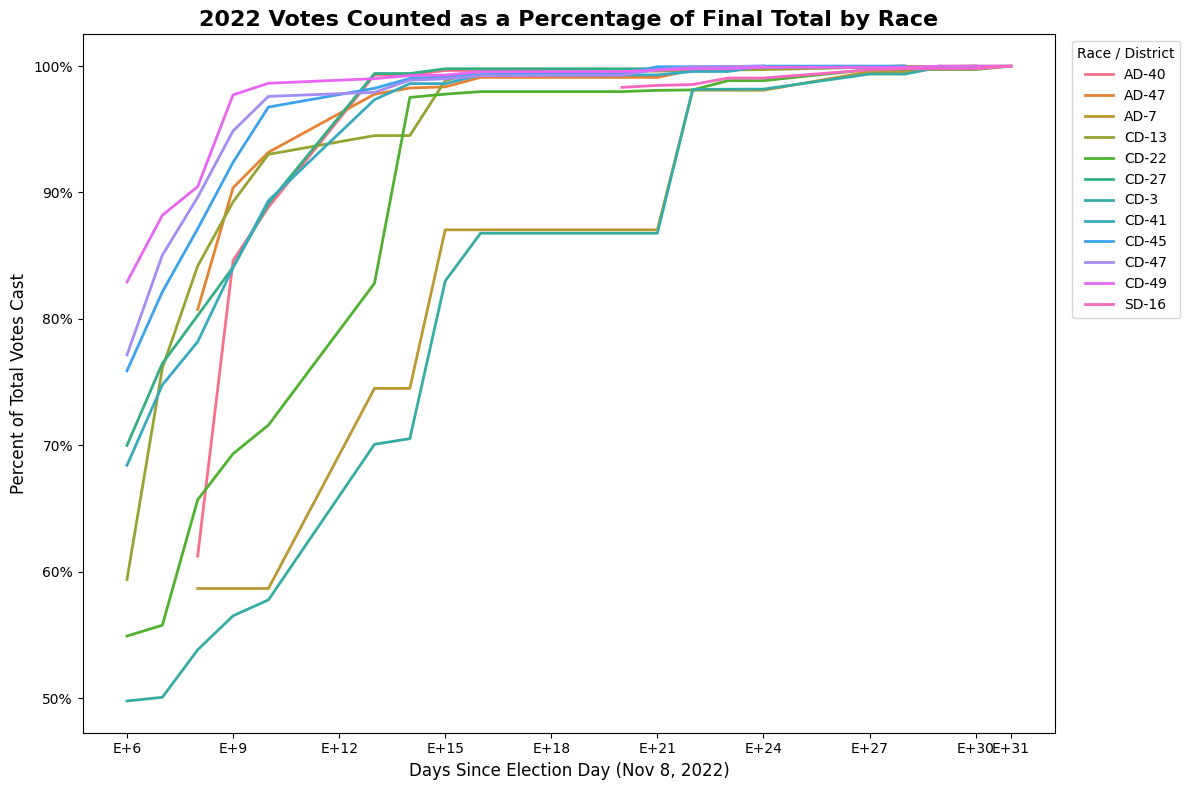

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

ELECTION_DAY = pd.to_datetime('2022-11-08')

# Votes counted as % of final total
final_df['Final_Total_Votes'] = final_df.groupby('Race')['Total Votes Cast'].transform('max')
final_df['Percent_of_Final'] = final_df['Total Votes Cast'] / final_df['Final_Total_Votes']
final_df['Days_Since_Election'] = (final_df['Date'] - ELECTION_DAY).dt.days

plt.figure(figsize=(12, 8))
sns.lineplot(data=final_df, x='Days_Since_Election', y='Percent_of_Final', hue='Race', linewidth=2)
plt.title('2022 Votes Counted as a Percentage of Final Total by Race', fontsize=16, fontweight='bold')
plt.ylabel('Percent of Total Votes Cast', fontsize=12)
plt.xlabel('Days Since Election Day (Nov 8, 2022)', fontsize=12)

min_day = int(final_df['Days_Since_Election'].min())
max_day = int(final_df['Days_Since_Election'].max())
tick_interval = 3
spaced_ticks = list(range(min_day, max_day + 1, tick_interval))
if max_day not in spaced_ticks:
    spaced_ticks.append(max_day)
plt.xticks(ticks=spaced_ticks, labels=[f'E+{i}' for i in spaced_ticks])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Race / District')
plt.tight_layout()
plt.show()

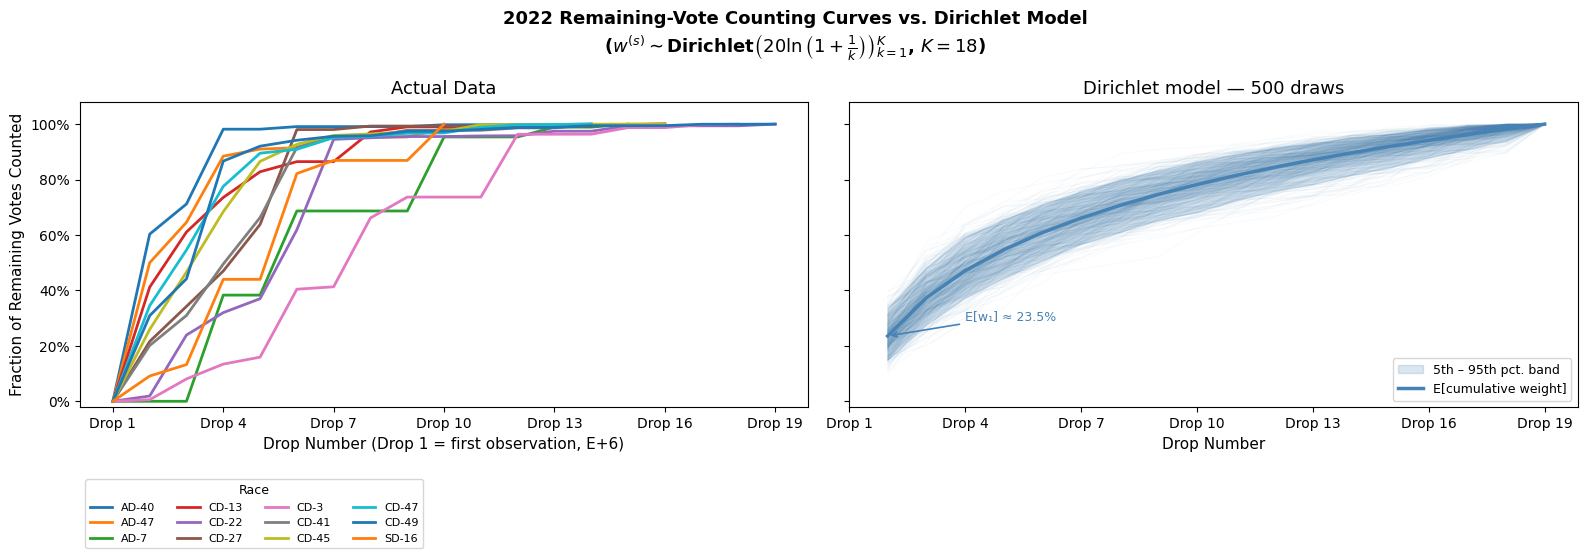

K (remaining drops modelled by Dirichlet): 18
Model E[w₁] (fraction of remaining votes in drop 2): 23.5%
Model E[cumulative through drop 5]:                   60.9%


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from numpy.random import default_rng

# Remaining-vote counting curves vs. Dirichlet model
# x-axis = drop number (sequential), not calendar days, since 2022 drops are not daily
p1 = (final_df[final_df['Day_Index'] == 1]
      .set_index('Race')['Percent_of_Final'])

plot_df = final_df[final_df['Day_Index'] >= 1].copy()
plot_df['p1'] = plot_df['Race'].map(p1)
plot_df['Remaining_Frac'] = (plot_df['Percent_of_Final'] - plot_df['p1']) / (1 - plot_df['p1'])
plot_df['Step'] = plot_df['Day_Index'] - 1

K = int(plot_df['Step'].max())
alpha = np.array([20 * np.log(1 + 1/k) for k in range(1, K + 1)])

n_sim = 500
rng = default_rng(42)
sim_weights = rng.dirichlet(alpha, size=n_sim)
sim_cumsum  = np.cumsum(sim_weights, axis=1)
step_idx    = np.arange(1, K + 1)

expected_w      = alpha / alpha.sum()
expected_cumsum = np.cumsum(expected_w)

spaced_ticks = list(range(0, K + 1, 3))
if K not in spaced_ticks:
    spaced_ticks.append(K)
# Labels show drop number (1-indexed): Drop 1 = first observation (E+6 in 2022)
tick_labels = [f'Drop {i+1}' for i in spaced_ticks]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('2022 Remaining-Vote Counting Curves vs. Dirichlet Model\n'
             r'($w^{(s)}\sim$Dirichlet$\left(20\ln\left(1+\frac{1}{k}\right)\right)_{k=1}^{K}$, '
             f'$K={K}$)',
             fontsize=13, fontweight='bold')

ax = axes[0]
palette = sns.color_palette('tab10', n_colors=plot_df['Race'].nunique())
for (race, grp), color in zip(plot_df.groupby('Race'), palette):
    grp = grp.sort_values('Step')
    ax.plot(grp['Step'], grp['Remaining_Frac'], color=color, linewidth=2, label=race)
ax.set_title('Actual Data', fontsize=13)
ax.set_xlabel('Drop Number (Drop 1 = first observation, E+6)', fontsize=11)
ax.set_ylabel('Fraction of Remaining Votes Counted', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(-0.02, 1.08)
ax.set_xticks(spaced_ticks); ax.set_xticklabels(tick_labels)
ax.legend(bbox_to_anchor=(0, -0.22), loc='upper left', ncol=4,
          title='Race', fontsize=8, title_fontsize=9)

ax = axes[1]
for i in range(n_sim):
    ax.plot(step_idx, sim_cumsum[i], color='steelblue', alpha=0.04, linewidth=0.7)
p5  = np.percentile(sim_cumsum,  5, axis=0)
p95 = np.percentile(sim_cumsum, 95, axis=0)
ax.fill_between(step_idx, p5, p95, color='steelblue', alpha=0.20, label='5th – 95th pct. band')
ax.plot(step_idx, expected_cumsum, color='steelblue', linewidth=2.5,
        label='E[cumulative weight]', zorder=5)
ax.annotate(f'E[w₁] ≈ {expected_w[0]:.1%}',
            xy=(1, expected_cumsum[0]),
            xytext=(3, expected_cumsum[0] + 0.06),
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))
ax.set_title(f'Dirichlet model — {n_sim} draws', fontsize=13)
ax.set_xlabel('Drop Number', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(-0.02, 1.08)
ax.set_xticks(spaced_ticks); ax.set_xticklabels(tick_labels)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"K (remaining drops modelled by Dirichlet): {K}")
print(f"Model E[w₁] (fraction of remaining votes in drop 2): {expected_w[0]:.1%}")
print(f"Model E[cumulative through drop 5]:                   {expected_cumsum[4]:.1%}")

In [31]:
# Empirical-Bayes summary table
# For each race: baseline (first observed drop), final, total shift Delta_r = F_r - p_r^(baseline)
eb_df = final_df.sort_values(['Race', 'Date']).copy()

race_summary = pd.DataFrame({
    'p_baseline': eb_df.groupby('Race')['Dem_Share'].first(),
    'p_final': eb_df.groupby('Race')['Dem_Share'].last(),
    'baseline_day': eb_df.groupby('Race')['Days_Since_Election'].first(),
    'n_drops': eb_df.groupby('Race')['Date'].count(),
})
race_summary['Delta_r'] = race_summary['p_final'] - race_summary['p_baseline']
race_summary

,p_baseline,p_final,baseline_day,n_drops,Delta_r
Race,,,,,
AD-40,0.504647,0.501640,8,14,-0.003007
AD-47,0.504105,0.499749,8,16,-0.004355
AD-7,0.504647,0.495838,8,15,-0.008809
CD-13,0.499470,0.497889,6,16,-0.001582
CD-22,0.474520,0.484765,6,19,0.010244
CD-27,0.445978,0.467606,6,16,0.021628
CD-3,0.470411,0.463517,6,18,-0.006894
CD-41,0.487443,0.476546,6,14,-0.010897
CD-45,0.462142,0.475868,6,16,0.013726


In [32]:
# SD-16 first observed at E+20 with only 10 drops — drop as outlier
EXCLUDE = ['SD-16']
races_used = race_summary.drop(EXCLUDE, errors='ignore')

# mu_g_hat: mean shift from E+6 baseline to final
# sigma_r_hat: race-level SD of Delta_r (with one election, this absorbs both s_g realization and s_r variance)
mu_g_hat = races_used['Delta_r'].mean()
sigma_r_hat = races_used['Delta_r'].std(ddof=1)

# sigma_eps_hat: pooled SD of (p_{r,t} - F_r) across all batches and races
resid = eb_df[~eb_df['Race'].isin(EXCLUDE)].merge(
    races_used[['p_final']], left_on='Race', right_index=True
)
resid['residual'] = resid['Dem_Share'] - resid['p_final']
sigma_eps_hat = resid['residual'].std(ddof=1)

print(f"Races used: {len(races_used)}   excluded: {EXCLUDE}")
print(f"mu_g_hat       = {mu_g_hat:+.5f}    (mean E+6 -> final Dem-share shift)")
print(f"sigma_r_hat    = {sigma_r_hat:.5f}    (sample SD of Delta_r across races)")
print(f"sigma_eps_hat  = {sigma_eps_hat:.5f}    (pooled SD of p_(r,t) - F_r)")

Races used: 11   excluded: ['SD-16']
mu_g_hat       = +0.00137    (mean E+6 -> final Dem-share shift)
sigma_r_hat    = 0.01018    (sample SD of Delta_r across races)
sigma_eps_hat  = 0.00506    (pooled SD of p_(r,t) - F_r)


In [33]:
import numpy as np

# Semi-informative priors anchored on 2022 (E+6 baseline)
# tau inflates the mu_g prior to absorb the E+3 -> E+6 offset and year-to-year drift
tau = max(abs(mu_g_hat), sigma_r_hat)
s_logn = 0.5  # LogNormal scale (in log space) for variance priors

print("Recommended 2024 priors (semi-informative, anchored on 2022 E+6 baseline)")
print("-" * 72)
print(f"  mu_g       ~ Normal({mu_g_hat:+.5f}, {tau:.5f}^2)")
print(f"  sigma_g    ~ HalfNormal(0.05)                          # unchanged")
print(f"  sigma_r    ~ LogNormal({np.log(sigma_r_hat):+.5f}, {s_logn})")
print(f"  sigma_eps  ~ LogNormal({np.log(sigma_eps_hat):+.5f}, {s_logn})")
print()
print("95% prior intervals:")
print(f"  mu_g:        [{mu_g_hat - 1.96*tau:+.5f}, {mu_g_hat + 1.96*tau:+.5f}]")
print(f"  sigma_r:     [{sigma_r_hat * np.exp(-1.96*s_logn):.5f}, {sigma_r_hat * np.exp(1.96*s_logn):.5f}]")
print(f"  sigma_eps:   [{sigma_eps_hat * np.exp(-1.96*s_logn):.5f}, {sigma_eps_hat * np.exp(1.96*s_logn):.5f}]")

Recommended 2024 priors (semi-informative, anchored on 2022 E+6 baseline)
------------------------------------------------------------------------
  mu_g       ~ Normal(+0.00137, 0.01018^2)
  sigma_g    ~ HalfNormal(0.05)                          # unchanged
  sigma_r    ~ LogNormal(-4.58738, 0.5)
  sigma_eps  ~ LogNormal(-5.28708, 0.5)

95% prior intervals:
  mu_g:        [-0.01858, +0.02133]
  sigma_r:     [0.00382, 0.02712]
  sigma_eps:   [0.00190, 0.01347]


In [34]:
import json
import os

eb_priors = {
    'baseline': 'E+6',
    'n_races': int(len(races_used)),
    'excluded_races': EXCLUDE,
    'mu_g_hat': float(mu_g_hat),
    'sigma_r_hat': float(sigma_r_hat),
    'sigma_eps_hat': float(sigma_eps_hat),
    'tau_mu_g': float(tau),
    'lognormal_sigma_for_variance_priors': float(s_logn),
}

os.makedirs('../2022_output', exist_ok=True)
with open('../2022_output/eb_priors.json', 'w') as f:
    json.dump(eb_priors, f, indent=2)

print('Saved to ../2022_output/eb_priors.json')
print(json.dumps(eb_priors, indent=2))

Saved to ../2022_output/eb_priors.json
{
  "baseline": "E+6",
  "n_races": 11,
  "excluded_races": [
    "SD-16"
  ],
  "mu_g_hat": 0.0013748270741872398,
  "sigma_r_hat": 0.01017952831506951,
  "sigma_eps_hat": 0.005056496765860767,
  "tau_mu_g": 0.01017952831506951,
  "lognormal_sigma_for_variance_priors": 0.5
}
